In [1]:
%pip install langgraph


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o-mini")
model.invoke("안녕하세요!")

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D71Pc9QOEEphfZMXsjhdTT0K0TwqO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c3df6-94dd-78c2-886f-ddd61a085afe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """
    messages: Annotated[list[str], add_messages]

graph_builder = StateGraph(State)

In [4]:
def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
            형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [5]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

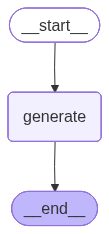

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
response = graph.invoke({"messages": ["안녕하세요! 저는 이성용입니다."]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다.', additional_kwargs={}, response_metadata={}, id='982cfad1-8a27-4b0a-b2f7-fdb78c1216b1'),
  AIMessage(content='안녕하세요, 이성용님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 16, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D7MYGY5qiOqE7O2wSyJJGcxM4IIyz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c42ce-8192-7873-ad70-880e493bb2a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 21, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [8]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다.', additional_kwargs={}, response_metadata={}, id='982cfad1-8a27-4b0a-b2f7-fdb78c1216b1'),
  AIMessage(content='안녕하세요, 이성용님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 16, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D7MYGY5qiOqE7O2wSyJJGcxM4IIyz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c42ce-8192-7873-ad70-880e493bb2a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 21, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [9]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려 줘.")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적으로 복잡하고 다면적인 측면을 가지고 있습니다. 두 국가는 지리적으로 가깝고 경제적으로도 중요한 파트너지만, 역사적 갈등과 정치적 긴장이 상존해 있습니다.

### 1. 역사적 배경
- **조선시대**: 한국과 일본은 오랜 역사를 공유하고 서로의 문화에 영향을 주고받았습니다. 그러나 이 시기에도 두 나라 사이의 갈등은 존재했습니다.
- **일제강점기 (1910-1945)**: 일본은 한국을 식민지로 지배하였고, 이 시기에 많은 한국인들이 고통을 받았습니다. 강제징용, 위안부 문제 등은 현재까지도 한일관계의 주요 갈등 요소로 여겨집니다.
  
### 2. 현대의 관계
- **정치적 갈등**: 역사 문제로 인해 두 나라 사이에는 여러 불만이 존재합니다. 일본의 교과서 문제, 한국의 위안부 및 강제징용 관련 판결 등은 양국 간의 대립을 심화시킵니다.
- **경제적 관계**: 경제적으로 두 나라는 서로 의존하고 있습니다. 일본은 한국의 주요 수출국 중 하나이며, 한국도 일본에 중요한 시장입니다. 그러나 2019년 일본의 수출 규제가 발효되면서 경제적 긴장이 더욱 고조되었습니다.
  
### 3. 외교 노선
- **안보 협력**: 북한의 핵 위협 등을 고려할 때, 미국과의 삼각 동맹으로서의 안보 협력이 필요하다고 인식하고 있습니다. 하지만 역사 문제와 정치적 갈등이 외교 관계에 복잡성을 더하고 있습니다.
- **문화 교류**: K-팝, 드라마 등 한국의 대중문화가 일본에서 인기를 끌고 있으며, 문화 교류가 활발히 이루어지고 있습니다. 이러한 문화적 교류는 양국 간의 이해를 도모할 수 있는 긍정적인 요소입니다.

### 4. 최근 동향
최근에는 양국 정부가 외교적 대화를 재개하려는 움직임이 보이고 있지만, 역사 문제와 일본의 방위 정책 변화 등의 이슈가 여전히 큰 걸림돌로 작용하고 있습니다.

한국과 일본의 관계는 끊임없이 변화하고 있으며, 역사적 갈등을 극복하고 상호 이해를 늘려가는 것이 중요합니다. 양국 간의 미래 관계는 서로의 역사와 문화